In [1]:
from facial_landmarks.facial_processor import FacialLandmarkProcessor, ProcessingConfig
import cv2
import matplotlib.pyplot as plt

In [46]:
# Configure model properties and create facial landmark model
config = ProcessingConfig(
    enable_face_detection = True,
    draw_face_boxes = True,
    draw_landmarks = False,
    draw_face_keypoints = False,
    draw_detailed_landmarks = False,
    landmark_tracking_confidence = 0.99
)

model = FacialLandmarkProcessor(config)

I0000 00:00:1773409716.522525  273335 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1773409716.526319  376666 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.1), renderer: Mesa Intel(R) Iris(R) Xe Graphics (ADL GT2)
W0000 00:00:1773409716.530855  376658 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1773409716.542978  273335 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1773409716.547406  376689 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.1), renderer: Mesa Intel(R) Iris(R) Xe Graphics (ADL GT2)
W0000 00:00:1773409716.557123  376673 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


W0000 00:00:1773409716.592933  376668 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Found 1 face.
Found 478 landmarks.
Processing time: 23.5ms


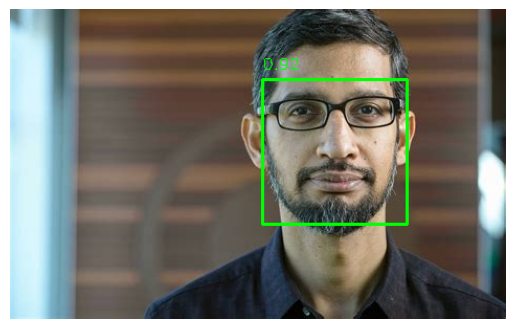

In [71]:
# Load image and process
img = cv2.imread("../pictures/google_ceo.jpg")
result = model.process_image(img)

# Access results
print(f"Found {len(result.faces)} face{'s' if len(result.faces) != 1 else ''}.")
if not result.landmarks:
    print(f"No landmarks detected.")
else:
    print(f"Found {len(result.landmarks[0].landmarks)} landmarks.")
print(f"Processing time: {result.processing_time*1000:.1f}ms")

# Show results
plt.imshow(cv2.cvtColor(result.processed_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

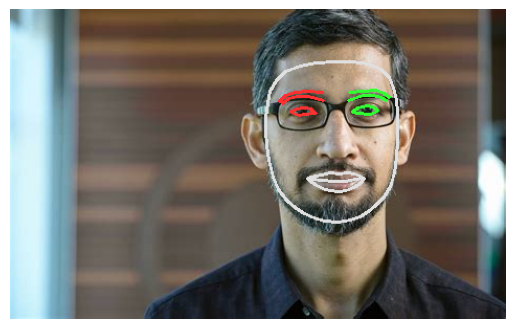

In [72]:
# Show contours of face
annotated = model.landmark_detector.draw_landmarks(img, result.landmarks)

# Show results
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

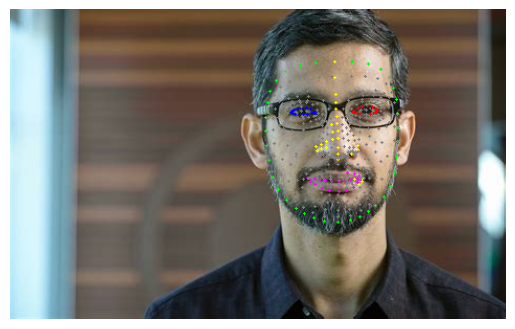

In [73]:
# Show detailed landmarks
annotated = model.landmark_detector.draw_landmarks(img, result.landmarks, draw_connections=False)

# Show results
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

Found 1 face.
No landmarks detected.
Processing time: 15.0ms


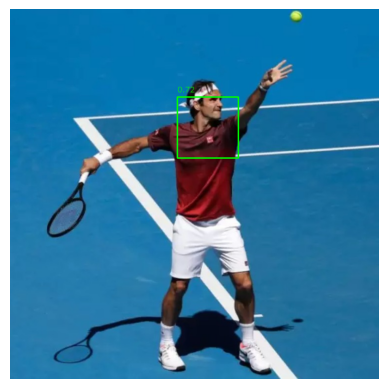

In [74]:
# Working with a slightly harder image, we can see that the model still detects the face, but doesn't find any landmarks
img = cv2.imread("../pictures/sample.jpg")
result = model.process_image(img)

# Access results
print(f"Found {len(result.faces)} face{'s' if len(result.faces) != 1 else ''}.")
if not result.landmarks:
    print(f"No landmarks detected.")
else:
    print(f"Found {len(result.landmarks[0].landmarks)} landmarks.")
print(f"Processing time: {result.processing_time*1000:.1f}ms")

# Show results
plt.imshow(cv2.cvtColor(result.processed_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [41]:
model.process_webcam()

Starting webcam processing. Press 'q' to quit.

Interrupted by user
